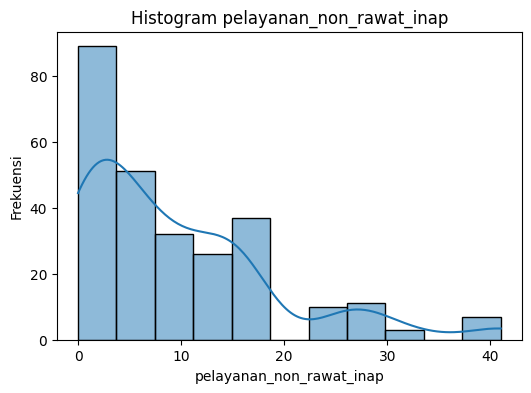

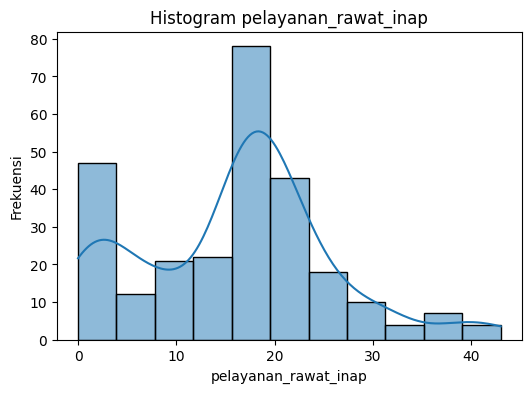

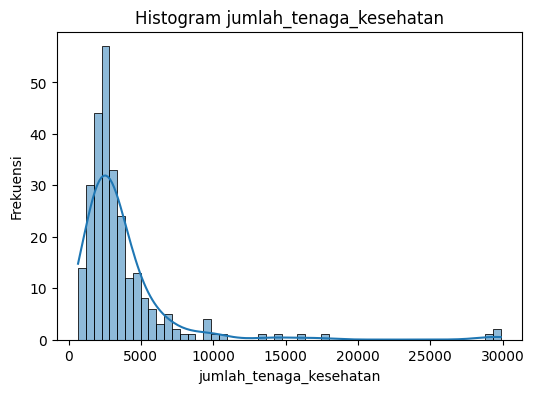

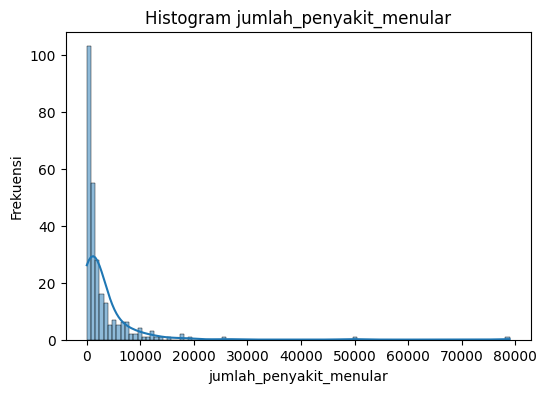

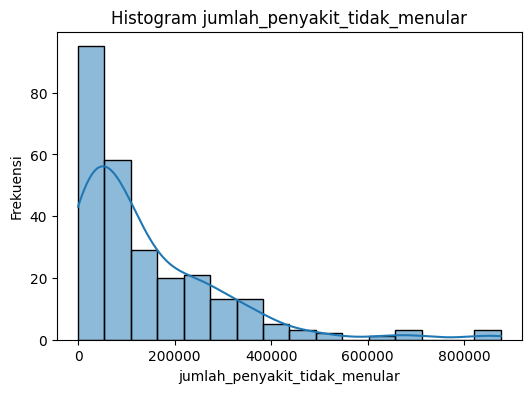

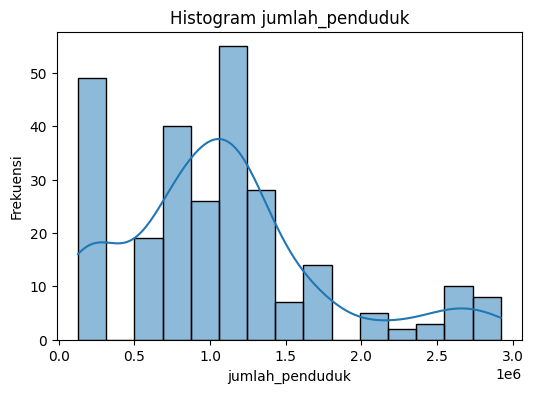

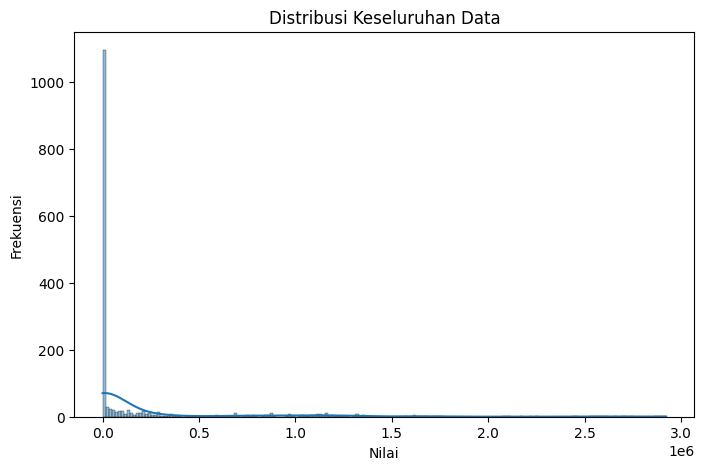

===== HASIL SKEWNESS =====

pelayanan_non_rawat_inap
Skewness: 1.379
Distribusi miring ke kanan (positive skew)

pelayanan_rawat_inap
Skewness: 0.251
Distribusi relatif simetris

jumlah_tenaga_kesehatan
Skewness: 4.843
Distribusi miring ke kanan (positive skew)

jumlah_penyakit_menular
Skewness: 7.571
Distribusi miring ke kanan (positive skew)

jumlah_penyakit_tidak_menular
Skewness: 1.997
Distribusi miring ke kanan (positive skew)

jumlah_penduduk
Skewness: 0.907
Distribusi miring ke kanan (positive skew)

===== UJI NORMALITAS SHAPIRO-WILK =====

pelayanan_non_rawat_inap
Statistic : 0.8486
p-value   : 0.0000
Distribusi tidak normal

pelayanan_rawat_inap
Statistic : 0.9447
p-value   : 0.0000
Distribusi tidak normal

jumlah_tenaga_kesehatan
Statistic : 0.5288
p-value   : 0.0000
Distribusi tidak normal

jumlah_penyakit_menular
Statistic : 0.3874
p-value   : 0.0000
Distribusi tidak normal

jumlah_penyakit_tidak_menular
Statistic : 0.8007
p-value   : 0.0000
Distribusi tidak normal

jumlah_

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, shapiro

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('dataset_fasilitas_kesehatan_skripsi.csv')  # ganti sesuai nama file kamu

# =========================
# PILIH VARIABEL
# =========================
cols = [
    'pelayanan_non_rawat_inap',
    'pelayanan_rawat_inap',
    'jumlah_tenaga_kesehatan',
    'jumlah_penyakit_menular',
    'jumlah_penyakit_tidak_menular',
    'jumlah_penduduk'
]

data = df[cols]

# =========================
# HISTOGRAM SEMUA VARIABEL
# =========================
for col in cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)

    plt.title(f'Histogram {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')

    plt.show()


# =========================
# DISTRIBUSI KESELURUHAN DATA
# =========================
all_values = data.values.flatten()

plt.figure(figsize=(8,5))

sns.histplot(all_values, kde=True)

plt.title('Distribusi Keseluruhan Data')
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')

plt.show()

# =========================
# SKEWNESS
# =========================
print("===== HASIL SKEWNESS =====")

for col in cols:
    nilai_skew = skew(data[col].dropna())

    print(f'\n{col}')
    print(f'Skewness: {nilai_skew:.3f}')

    if -0.5 <= nilai_skew <= 0.5:
        print("Distribusi relatif simetris")
    elif nilai_skew > 0.5:
        print("Distribusi miring ke kanan (positive skew)")
    else:
        print("Distribusi miring ke kiri (negative skew)")

# =========================
# UJI NORMALITAS
# =========================
print("\n===== UJI NORMALITAS SHAPIRO-WILK =====")

for col in cols:

    sample_data = data[col].dropna()

    # jika data terlalu besar
    if len(sample_data) > 5000:
        sample_data = sample_data.sample(5000, random_state=42)

    stat, p = shapiro(sample_data)

    print(f'\n{col}')
    print(f'Statistic : {stat:.4f}')
    print(f'p-value   : {p:.4f}')

    if p > 0.05:
        print("Distribusi normal")
    else:
        print("Distribusi tidak normal")

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('dataset_fasilitas_kesehatan_skripsi.csv')  # ganti sesuai nama file kamu

# =========================
# PILIH VARIABEL
# =========================
cols = [
    'pelayanan_non_rawat_inap',
    'pelayanan_rawat_inap',
    'jumlah_tenaga_kesehatan',
    'jumlah_penyakit_menular',
    'jumlah_penyakit_tidak_menular',
    'jumlah_penduduk'
]

data = df[cols]

# =========================
# DETEKSI OUTLIER METODE IQR
# =========================
print("===== HASIL DETEKSI OUTLIER =====")

for col in cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower_bound) |
        (data[col] > upper_bound)
    ]

    jumlah_outlier = len(outliers)
    persentase = (jumlah_outlier / len(data)) * 100

    print(f'\nVariabel : {col}')
    print(f'Jumlah outlier      : {jumlah_outlier}')
    print(f'Persentase outlier  : {persentase:.2f}%')

    # Interpretasi sederhana
    if persentase < 5:
        print("Outlier sedikit")
    elif persentase < 15:
        print("Outlier sedang")
    else:
        print("Outlier banyak")

===== HASIL DETEKSI OUTLIER =====

Variabel : pelayanan_non_rawat_inap
Jumlah outlier      : 7
Persentase outlier  : 2.63%
Outlier sedikit

Variabel : pelayanan_rawat_inap
Jumlah outlier      : 4
Persentase outlier  : 1.50%
Outlier sedikit

Variabel : jumlah_tenaga_kesehatan
Jumlah outlier      : 22
Persentase outlier  : 8.27%
Outlier sedang

Variabel : jumlah_penyakit_menular
Jumlah outlier      : 29
Persentase outlier  : 10.90%
Outlier sedang

Variabel : jumlah_penyakit_tidak_menular
Jumlah outlier      : 10
Persentase outlier  : 3.76%
Outlier sedikit

Variabel : jumlah_penduduk
Jumlah outlier      : 21
Persentase outlier  : 7.89%
Outlier sedang
